# Step 5 — Cosine Similarity
**Project:** Same Reality, Different Words  
**Author:** Paula Andrea Jaramillo  
**Program:** MSc Data Science for Society and Business — Constructor University Bremen

## Objective
Measure **semantic similarity** between documents and between register centroids using cosine similarity over the TF-IDF vectors computed in Step 4.

**Two analytical layers:**
1. **Centroid-level similarity** — how similar are the three registers to each other as a whole? High inter-register distance = strong semantic divergence
2. **Document-level similarity** — within each register, how cohesive are the documents? And how far are documents from the centroids of *other* registers?

**Connection to research hypotheses:**
- **H2 (continued):** If registers are semantically divergent, inter-register cosine similarity should be significantly lower than intra-register similarity
- **H3 (groundwork):** Documents with high similarity to a *different* register's centroid are candidates for misclassification in Step 6 — these mark the semantic boundary zones

**Input:** `tfidf_matrix.npz`, `corpus_tfidf_meta.csv` (outputs of Step 4)  
**Output:** `cosine_similarity_results.csv` (per-document similarity scores to each register centroid)

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Load Inputs from Step 4

In [2]:
# Load TF-IDF matrix
tfidf_matrix = sp.load_npz("tfidf_matrix.npz")
print(f"TF-IDF matrix loaded: {tfidf_matrix.shape}")

# Load metadata (register + label aligned with matrix rows)
meta = pd.read_csv("corpus_tfidf_meta.csv")
print(f"Metadata loaded: {meta.shape}")
print(f"Registers: {meta['register'].value_counts().to_dict()}")

# Sanity check: rows must match
assert tfidf_matrix.shape[0] == len(meta), \
    f"Row mismatch: matrix has {tfidf_matrix.shape[0]} rows, meta has {len(meta)}"
print("✅ Row alignment check passed")

meta.head(3)

TF-IDF matrix loaded: (180, 171)
Metadata loaded: (180, 3)
Registers: {'institutional': 60, 'popular_media': 60, 'critical_media': 60}
✅ Row alignment check passed


,prompt_id,register,label
0,A001,institutional,0
1,A002,institutional,0
2,A003,institutional,0


## 3. Compute Register Centroids

A **centroid** is the mean TF-IDF vector of all documents in a register.  
It represents the "average semantic profile" of that register.  
Cosine similarity between a document and a centroid measures how well that document fits its register's profile.

In [3]:
register_order = ["institutional", "popular_media", "critical_media"]
register_labels = ["Institutional", "Popular Media", "Critical Media"]

tfidf_dense = tfidf_matrix.toarray()

centroids = {}
for reg in register_order:
    mask = meta["register"] == reg
    centroids[reg] = tfidf_dense[mask].mean(axis=0, keepdims=True)
    print(f"Centroid [{reg}]: shape={centroids[reg].shape}, "
          f"non-zero dims={np.count_nonzero(centroids[reg])}")

Centroid [institutional]: shape=(1, 171), non-zero dims=106
Centroid [popular_media]: shape=(1, 171), non-zero dims=81
Centroid [critical_media]: shape=(1, 171), non-zero dims=118


## 4. Inter-Register Centroid Similarity

Pairwise cosine similarity between register centroids.  
Values close to 0 indicate high semantic divergence; values close to 1 indicate near-identical profiles.

**Expected result:** institutional vs. critical_media should show the lowest similarity (most divergent registers semantically).

In [4]:
centroid_matrix = np.vstack([centroids[reg] for reg in register_order])
centroid_sim = cosine_similarity(centroid_matrix)

centroid_sim_df = pd.DataFrame(
    centroid_sim,
    index=register_labels,
    columns=register_labels
)

print("=== Pairwise cosine similarity between register centroids ===")
print(centroid_sim_df.round(4).to_string())

print("\n--- Interpretation ---")
pairs = [
    ("institutional", "popular_media"),
    ("institutional", "critical_media"),
    ("popular_media", "critical_media")
]
for r1, r2 in pairs:
    i, j = register_order.index(r1), register_order.index(r2)
    print(f"  {r1} vs {r2}: {centroid_sim[i, j]:.4f}")

=== Pairwise cosine similarity between register centroids ===
                Institutional  Popular Media  Critical Media
Institutional          1.0000         0.3247          0.7406
Popular Media          0.3247         1.0000          0.3017
Critical Media         0.7406         0.3017          1.0000

--- Interpretation ---
  institutional vs popular_media: 0.3247
  institutional vs critical_media: 0.7406
  popular_media vs critical_media: 0.3017


## 5. Document-to-Centroid Similarity

For each document, compute its cosine similarity to **each** of the three register centroids.  
This produces three scores per document:
- `sim_institutional` — how much the document resembles the institutional profile
- `sim_popular_media` — how much it resembles popular media
- `sim_critical_media` — how much it resembles critical media

The **predicted register by similarity** is the centroid with the highest score.  
Documents where predicted ≠ true register are **semantic boundary candidates** (H3 evidence).

In [5]:
sim_scores = {}
for reg in register_order:
    sim_col = f"sim_{reg}"
    sims = cosine_similarity(tfidf_dense, centroids[reg]).flatten()
    sim_scores[sim_col] = sims

sim_df = pd.DataFrame(sim_scores)
sim_df["predicted_register"] = sim_df[[f"sim_{r}" for r in register_order]].idxmax(axis=1)
sim_df["predicted_register"] = sim_df["predicted_register"].str.replace("sim_", "")

# Merge with metadata
results = pd.concat([meta.reset_index(drop=True), sim_df], axis=1)
results["sim_match"] = results["register"] == results["predicted_register"]

print(f"Overall similarity-based accuracy: "
      f"{results['sim_match'].mean():.3f} ({results['sim_match'].sum()}/{len(results)})")
print()
print("Accuracy by register:")
print(results.groupby("register")["sim_match"].mean().round(3).to_string())

results[["prompt_id", "register", "sim_institutional", "sim_popular_media",
         "sim_critical_media", "predicted_register", "sim_match"]].head(6)

Overall similarity-based accuracy: 0.861 (155/180)

Accuracy by register:
register
critical_media    0.833
institutional     0.850
popular_media     0.900


,prompt_id,register,sim_institutional,sim_popular_media,sim_critical_media,predicted_register,sim_match
0,A001,institutional,0.359784,0.137593,0.348594,institutional,True
1,A002,institutional,0.273313,0.109844,0.200340,institutional,True
2,A003,institutional,0.289879,0.100684,0.216953,institutional,True
3,A004,institutional,0.452886,0.077915,0.222768,institutional,True
4,A005,institutional,0.301984,0.171761,0.190716,institutional,True
5,A006,institutional,0.400326,0.102081,0.243905,institutional,True


## 6. Intra- vs Inter-Register Similarity

For each document, compare:
- **Intra-register similarity**: similarity to its own register's centroid
- **Inter-register similarity**: mean similarity to the *other two* register centroids

A well-separated corpus should show intra > inter for most documents.

In [6]:
def get_intra_sim(row):
    return row[f"sim_{row['register']}"]

def get_inter_sim(row):
    other_regs = [r for r in register_order if r != row["register"]]
    return np.mean([row[f"sim_{r}"] for r in other_regs])

results["sim_intra"] = results.apply(get_intra_sim, axis=1)
results["sim_inter"] = results.apply(get_inter_sim, axis=1)
results["sim_gap"] = results["sim_intra"] - results["sim_inter"]

print("=== Intra vs Inter-Register Similarity ===")
summary = results.groupby("register")[["sim_intra", "sim_inter", "sim_gap"]].mean().round(4)
print(summary.to_string())

print(f"\nOverall mean intra-register similarity: {results['sim_intra'].mean():.4f}")
print(f"Overall mean inter-register similarity: {results['sim_inter'].mean():.4f}")
print(f"Overall mean gap (intra - inter):       {results['sim_gap'].mean():.4f}")

docs_above = (results["sim_gap"] > 0).sum()
print(f"\nDocuments with intra > inter: {docs_above}/{len(results)} ({docs_above/len(results)*100:.1f}%)")

=== Intra vs Inter-Register Similarity ===
                sim_intra  sim_inter  sim_gap
register                                     
critical_media     0.3145     0.1639   0.1506
institutional      0.3405     0.1814   0.1591
popular_media      0.3140     0.0984   0.2156

Overall mean intra-register similarity: 0.3230
Overall mean inter-register similarity: 0.1479
Overall mean gap (intra - inter):       0.1751

Documents with intra > inter: 175/180 (97.2%)


## 7. H3 Groundwork — Semantic Boundary Documents

Documents with a **negative or near-zero similarity gap** (intra ≤ inter) are semantically ambiguous — they fit another register's profile as well as or better than their own.  
These are the **boundary zone** documents that H3 predicts will be misclassified in Step 6.

In [7]:
boundary_docs = results[results["sim_gap"] <= 0].sort_values("sim_gap")

print(f"Semantic boundary documents (sim_gap ≤ 0): {len(boundary_docs)}")
print()

if len(boundary_docs) > 0:
    print(boundary_docs[["prompt_id", "register", "predicted_register",
                          "sim_intra", "sim_inter", "sim_gap"]].to_string())
else:
    print("No boundary documents found — registers are well-separated by centroid similarity.")
    print("Note: Step 6 Logistic Regression may still misclassify some documents")
    print("due to within-class variance not captured by centroid distance alone.")

# Also flag near-boundary (gap < 0.05)
near_boundary = results[(results["sim_gap"] > 0) & (results["sim_gap"] < 0.05)]
print(f"\nNear-boundary documents (0 < sim_gap < 0.05): {len(near_boundary)}")

Semantic boundary documents (sim_gap ≤ 0): 5

    prompt_id       register predicted_register  sim_intra  sim_inter   sim_gap
73       B014  popular_media      institutional   0.176180   0.303762 -0.127582
70       B011  popular_media      institutional   0.204520   0.267056 -0.062536
98       B039  popular_media      institutional   0.204056   0.221768 -0.017712
104      B045  popular_media     critical_media   0.241046   0.254803 -0.013757
51       A052  institutional     critical_media   0.196272   0.199126 -0.002854

Near-boundary documents (0 < sim_gap < 0.05): 12


## 8. Visualizations

### 8.1 Centroid Similarity Heatmap

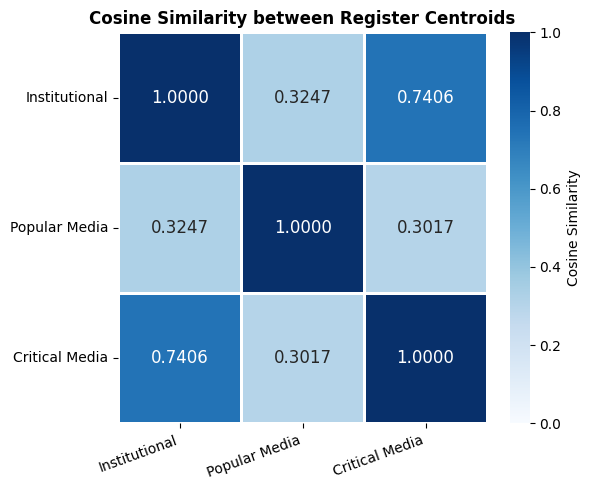

Figure saved: step5_centroid_heatmap.png


In [8]:
colors = ["#2E75B6", "#E67E22", "#27AE60"]

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.zeros_like(centroid_sim, dtype=bool)
np.fill_diagonal(mask, True)

sns.heatmap(
    centroid_sim_df, annot=True, fmt=".4f", cmap="Blues",
    linewidths=1, ax=ax, vmin=0, vmax=1,
    cbar_kws={"label": "Cosine Similarity"},
    annot_kws={"size": 12}
)
ax.set_title("Cosine Similarity between Register Centroids",
             fontsize=12, fontweight="bold")
ax.set_xticklabels(register_labels, rotation=20, ha="right", fontsize=10)
ax.set_yticklabels(register_labels, rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig("step5_centroid_heatmap.png", dpi=150)
plt.show()
print("Figure saved: step5_centroid_heatmap.png")

### 8.2 Document-to-Centroid Similarity — Boxplots per Register

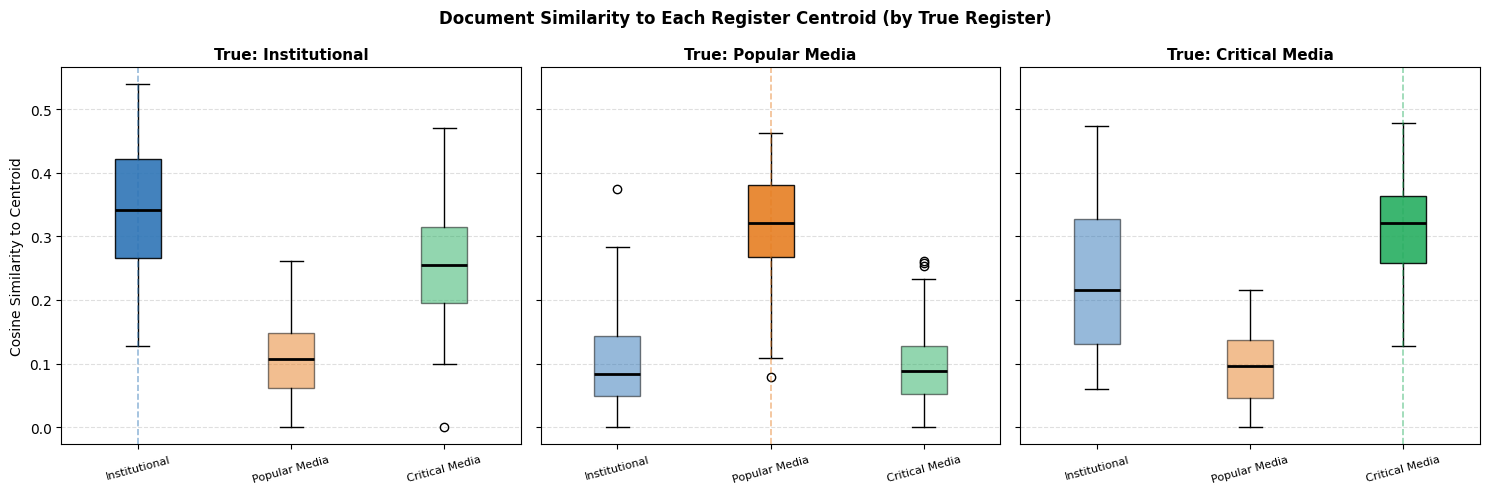

Figure saved: step5_doc_centroid_boxplots.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, reg, label, color in zip(axes, register_order, register_labels, colors):
    subset = results[results["register"] == reg]
    data = [subset[f"sim_{r}"].values for r in register_order]
    bp = ax.boxplot(data, labels=register_labels, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for i, (patch, c) in enumerate(zip(bp["boxes"], colors)):
        patch.set_facecolor(c)
        patch.set_alpha(0.5 if register_order[i] != reg else 0.9)
    ax.set_title(f"True: {label}", fontsize=11, fontweight="bold")
    ax.set_ylabel("Cosine Similarity to Centroid" if ax == axes[0] else "", fontsize=10)
    ax.tick_params(axis="x", labelsize=8, rotation=15)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    # Highlight own centroid
    ax.axvline(x=register_order.index(reg) + 1, color=color, linestyle="--",
               alpha=0.5, linewidth=1.2, label="own centroid")

plt.suptitle("Document Similarity to Each Register Centroid (by True Register)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("step5_doc_centroid_boxplots.png", dpi=150)
plt.show()
print("Figure saved: step5_doc_centroid_boxplots.png")

### 8.3 Intra vs Inter Similarity — Paired Boxplot

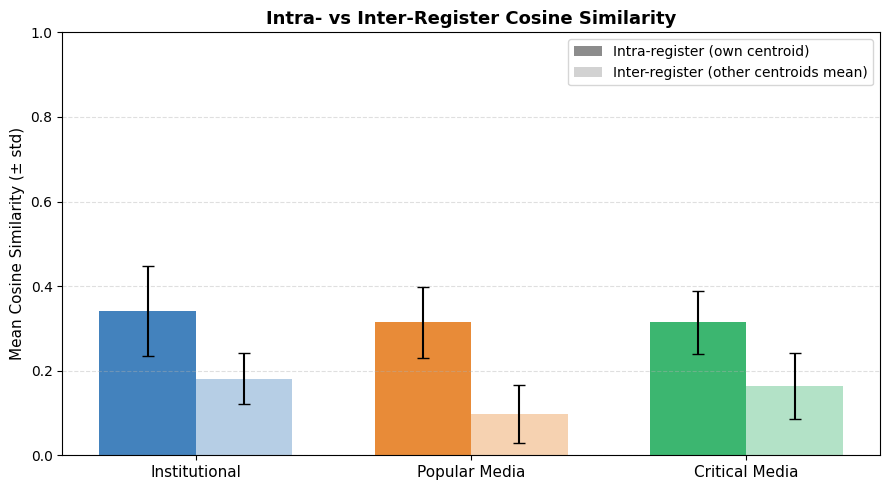

Figure saved: step5_intra_inter_similarity.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(register_order))
width = 0.35

for i, (reg, label, color) in enumerate(zip(register_order, register_labels, colors)):
    subset = results[results["register"] == reg]
    ax.bar(i - width/2, subset["sim_intra"].mean(), width,
           color=color, alpha=0.9, label=label if i == 0 else "",
           yerr=subset["sim_intra"].std(), capsize=4)
    ax.bar(i + width/2, subset["sim_inter"].mean(), width,
           color=color, alpha=0.35,
           yerr=subset["sim_inter"].std(), capsize=4)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="grey", alpha=0.9, label="Intra-register (own centroid)"),
    Patch(facecolor="grey", alpha=0.35, label="Inter-register (other centroids mean)")
]
ax.legend(handles=legend_elements, fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(register_labels, fontsize=11)
ax.set_ylabel("Mean Cosine Similarity (± std)", fontsize=11)
ax.set_title("Intra- vs Inter-Register Cosine Similarity",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("step5_intra_inter_similarity.png", dpi=150)
plt.show()
print("Figure saved: step5_intra_inter_similarity.png")

### 8.4 Similarity Gap Distribution — H3 Boundary Zones

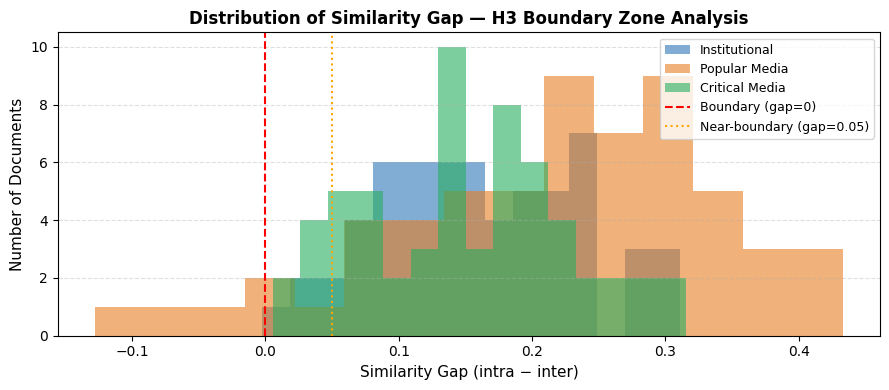

Figure saved: step5_similarity_gap.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 4))

for reg, label, color in zip(register_order, register_labels, colors):
    subset = results[results["register"] == reg]["sim_gap"]
    ax.hist(subset, bins=15, alpha=0.6, color=color, label=label)

ax.axvline(x=0, color="red", linestyle="--", linewidth=1.5, label="Boundary (gap=0)")
ax.axvline(x=0.05, color="orange", linestyle=":", linewidth=1.5, label="Near-boundary (gap=0.05)")
ax.set_xlabel("Similarity Gap (intra − inter)", fontsize=11)
ax.set_ylabel("Number of Documents", fontsize=11)
ax.set_title("Distribution of Similarity Gap — H3 Boundary Zone Analysis",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("step5_similarity_gap.png", dpi=150)
plt.show()
print("Figure saved: step5_similarity_gap.png")

## 9. H2 + H3 Evidence Summary

In [12]:
print("=== H2 EVIDENCE (Cosine Similarity) ===")
print("Pairwise centroid similarity:")
for r1, r2 in pairs:
    i, j = register_order.index(r1), register_order.index(r2)
    print(f"  {r1} vs {r2}: {centroid_sim[i, j]:.4f}")
print(f"\nMean intra-register similarity: {results['sim_intra'].mean():.4f}")
print(f"Mean inter-register similarity: {results['sim_inter'].mean():.4f}")
h2_supported = results['sim_intra'].mean() > results['sim_inter'].mean()
print(f"H2 supported by cosine similarity: {h2_supported}")

print("\n=== H3 GROUNDWORK ===")
print(f"Boundary documents (sim_gap ≤ 0): {len(boundary_docs)}")
print(f"Near-boundary documents (0 < gap < 0.05): {len(near_boundary)}")
total_ambiguous = len(boundary_docs) + len(near_boundary)
print(f"Total ambiguous documents: {total_ambiguous} ({total_ambiguous/len(results)*100:.1f}%)")
print("These are the predicted misclassification candidates for Step 6.")

=== H2 EVIDENCE (Cosine Similarity) ===
Pairwise centroid similarity:
  institutional vs popular_media: 0.3247
  institutional vs critical_media: 0.7406
  popular_media vs critical_media: 0.3017

Mean intra-register similarity: 0.3230
Mean inter-register similarity: 0.1479
H2 supported by cosine similarity: True

=== H3 GROUNDWORK ===
Boundary documents (sim_gap ≤ 0): 5
Near-boundary documents (0 < gap < 0.05): 12
Total ambiguous documents: 17 (9.4%)
These are the predicted misclassification candidates for Step 6.


## 10. Save Outputs

In [13]:
results.to_csv("cosine_similarity_results.csv", index=False)
print(f"Saved: cosine_similarity_results.csv — shape: {results.shape}")
print(f"Columns: {results.columns.tolist()}")

print("\nFiles ready for Step 6:")
print("  tfidf_matrix.npz              — feature matrix for classifier")
print("  corpus_tfidf_meta.csv         — labels")
print("  cosine_similarity_results.csv — boundary candidates for H3 analysis")

Saved: cosine_similarity_results.csv — shape: (180, 11)
Columns: ['prompt_id', 'register', 'label', 'sim_institutional', 'sim_popular_media', 'sim_critical_media', 'predicted_register', 'sim_match', 'sim_intra', 'sim_inter', 'sim_gap']

Files ready for Step 6:
  tfidf_matrix.npz              — feature matrix for classifier
  corpus_tfidf_meta.csv         — labels
  cosine_similarity_results.csv — boundary candidates for H3 analysis


## 11. Summary

In [14]:
print("=== STEP 5 SUMMARY ===")
print(f"Method: Cosine similarity over TF-IDF vectors (Step 4 output)")
print(f"Centroid similarity (inter-register):")
print(centroid_sim_df.round(4).to_string())
print(f"\nMean intra-register similarity: {results['sim_intra'].mean():.4f}")
print(f"Mean inter-register similarity: {results['sim_inter'].mean():.4f}")
print(f"Boundary zone documents: {len(boundary_docs) + len(near_boundary)}")
print("\nNext step: Step 6 — Logistic Regression Classifier")
print("Input files for Step 6: tfidf_matrix.npz, corpus_tfidf_meta.csv, cosine_similarity_results.csv")

=== STEP 5 SUMMARY ===
Method: Cosine similarity over TF-IDF vectors (Step 4 output)
Centroid similarity (inter-register):
                Institutional  Popular Media  Critical Media
Institutional          1.0000         0.3247          0.7406
Popular Media          0.3247         1.0000          0.3017
Critical Media         0.7406         0.3017          1.0000

Mean intra-register similarity: 0.3230
Mean inter-register similarity: 0.1479
Boundary zone documents: 17

Next step: Step 6 — Logistic Regression Classifier
Input files for Step 6: tfidf_matrix.npz, corpus_tfidf_meta.csv, cosine_similarity_results.csv
